In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score,classification_report
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [59]:
df = pd.read_csv("../dataset/dataset.csv")

In [60]:
df

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements,loss_of_balance,unsteadiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
df.shape

(4920, 18)

In [63]:
df.columns

Index(['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
       'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9',
       'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14',
       'Symptom_15', 'Symptom_16', 'Symptom_17'],
      dtype='str')

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Disease     4920 non-null   str  
 1   Symptom_1   4920 non-null   str  
 2   Symptom_2   4920 non-null   str  
 3   Symptom_3   4920 non-null   str  
 4   Symptom_4   4572 non-null   str  
 5   Symptom_5   3714 non-null   str  
 6   Symptom_6   2934 non-null   str  
 7   Symptom_7   2268 non-null   str  
 8   Symptom_8   1944 non-null   str  
 9   Symptom_9   1692 non-null   str  
 10  Symptom_10  1512 non-null   str  
 11  Symptom_11  1194 non-null   str  
 12  Symptom_12  744 non-null    str  
 13  Symptom_13  504 non-null    str  
 14  Symptom_14  306 non-null    str  
 15  Symptom_15  240 non-null    str  
 16  Symptom_16  192 non-null    str  
 17  Symptom_17  72 non-null     str  
dtypes: str(18)
memory usage: 1.2 MB


In [65]:
df.describe(include="all")

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
count,4920,4920,4920,4920,4572,3714,2934,2268,1944,1692,1512,1194,744,504,306,240,192,72
unique,41,34,48,54,50,38,32,26,21,22,21,18,11,8,4,3,3,1
top,Fungal infection,vomiting,vomiting,fatigue,high_fever,headache,nausea,abdominal_pain,abdominal_pain,yellowing_of_eyes,yellowing_of_eyes,irritability,malaise,muscle_pain,chest_pain,chest_pain,blood_in_sputum,muscle_pain
freq,120,822,870,726,378,348,390,264,276,228,198,120,126,72,96,144,72,72


In [66]:
df.isnull().sum()

Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(4616)

In [68]:
print("original: ", df.shape)
print("duplicated: ", df.drop_duplicates().shape)

original:  (4920, 18)
duplicated:  (304, 18)


In [69]:
df["Disease"].value_counts()

Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hepat

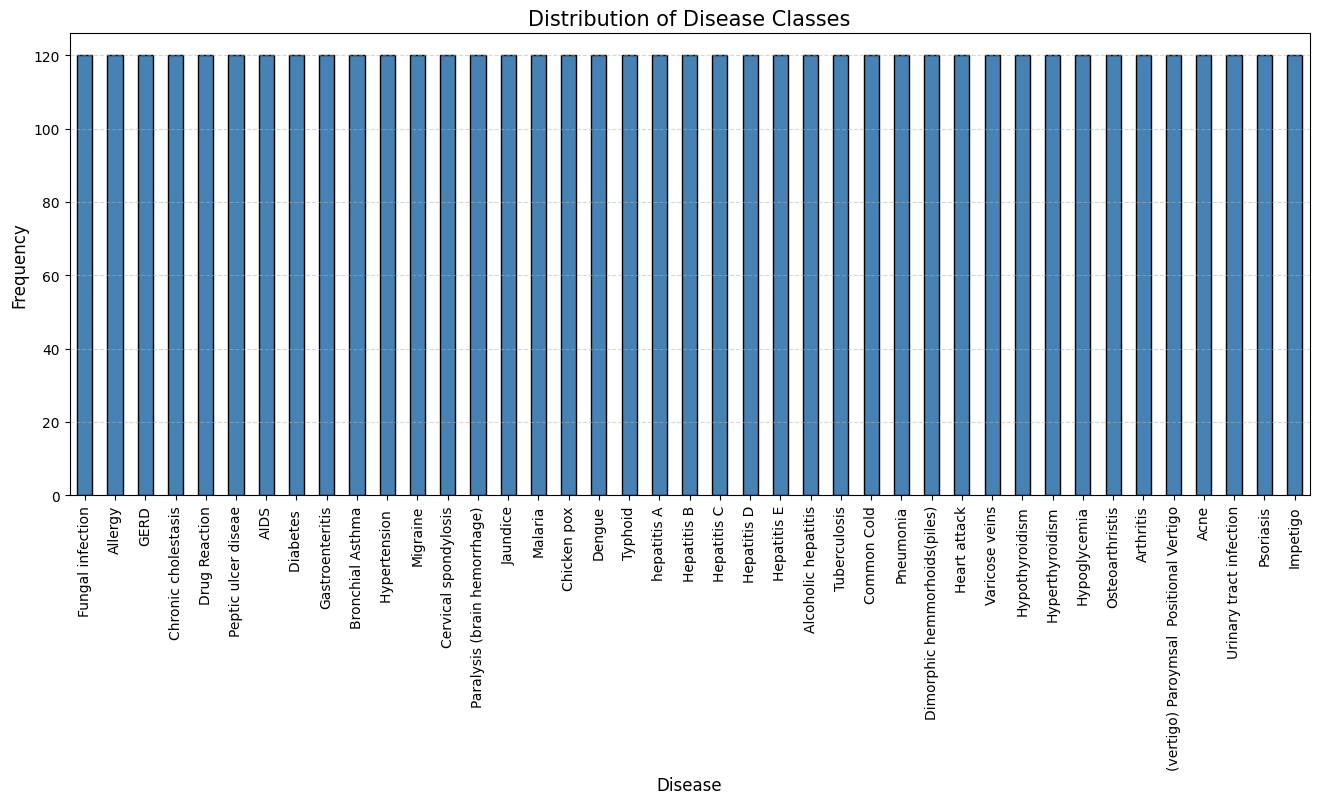

In [70]:
plt.figure(figsize=(16,6))

df["Disease"].value_counts().plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Disease Classes", fontsize=15)
plt.xlabel("Disease", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [71]:
all_symptoms = pd.unique(
    df.iloc[: , 1:].values.ravel()
)

all_symptomw = all_symptoms[pd.notna(all_symptoms)]
print("total unique symptoms: ", len(all_symptoms))

total unique symptoms:  132


In [72]:
all_symptoms = pd.unique(df.iloc[:, 1:].values.ravel())
all_symptoms = all_symptoms[pd.notna(all_symptoms)]

In [73]:
print(type(all_symptoms))
print(all_symptoms.dtype)

<class 'numpy.ndarray'>
object


In [74]:

for item in all_symptoms:
    if not isinstance(item, str):
        print(repr(item), type(item))

In [75]:
all_symptoms = pd.unique(df.iloc[:, 1:].values.ravel())

all_symptoms = [symptom for symptom in all_symptoms if pd.notna(symptom)]

print(any(pd.isna(all_symptoms)))
print(len(all_symptoms))

False
131


In [76]:
all_symptoms = sorted(
    symptom
    for symptom in pd.unique(df.iloc[:, 1:].values.ravel())
    if pd.notna(symptom)
)

print(all_symptoms)

[' abdominal_pain', ' abnormal_menstruation', ' acidity', ' acute_liver_failure', ' altered_sensorium', ' anxiety', ' back_pain', ' belly_pain', ' blackheads', ' bladder_discomfort', ' blister', ' blood_in_sputum', ' bloody_stool', ' blurred_and_distorted_vision', ' breathlessness', ' brittle_nails', ' bruising', ' burning_micturition', ' chest_pain', ' chills', ' cold_hands_and_feets', ' coma', ' congestion', ' constipation', ' continuous_feel_of_urine', ' continuous_sneezing', ' cough', ' cramps', ' dark_urine', ' dehydration', ' depression', ' diarrhoea', ' dischromic _patches', ' distention_of_abdomen', ' dizziness', ' drying_and_tingling_lips', ' enlarged_thyroid', ' excessive_hunger', ' extra_marital_contacts', ' family_history', ' fast_heart_rate', ' fatigue', ' fluid_overload', ' foul_smell_of urine', ' headache', ' high_fever', ' hip_joint_pain', ' history_of_alcohol_consumption', ' increased_appetite', ' indigestion', ' inflammatory_nails', ' internal_itching', ' irregular_su

In [87]:
symptom_columns = df.columns[1:]

df[symptom_columns] = df[symptom_columns].apply(
    lambda col: col.str.strip()
)

all_symptoms = pd.unique(df.iloc[:, 1:].values.ravel())
all_symptoms = all_symptoms[pd.notna(all_symptoms)]

print(sorted(all_symptoms))

['No_symptom', 'abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills', 'cold_hands_and_feets', 'coma', 'congestion', 'constipation', 'continuous_feel_of_urine', 'continuous_sneezing', 'cough', 'cramps', 'dark_urine', 'dehydration', 'depression', 'diarrhoea', 'dischromic _patches', 'distention_of_abdomen', 'dizziness', 'drying_and_tingling_lips', 'enlarged_thyroid', 'excessive_hunger', 'extra_marital_contacts', 'family_history', 'fast_heart_rate', 'fatigue', 'fluid_overload', 'foul_smell_of urine', 'headache', 'high_fever', 'hip_joint_pain', 'history_of_alcohol_consumption', 'increased_appetite', 'indigestion', 'inflammatory_nails', 'internal_itching', 'irregular_sugar_level', 'irritability', 'irritation

In [78]:
df[symptom_columns]= df[symptom_columns].fillna("No_symptom")

In [79]:
df[symptom_columns].isnull().sum()

Symptom_1     0
Symptom_2     0
Symptom_3     0
Symptom_4     0
Symptom_5     0
Symptom_6     0
Symptom_7     0
Symptom_8     0
Symptom_9     0
Symptom_10    0
Symptom_11    0
Symptom_12    0
Symptom_13    0
Symptom_14    0
Symptom_15    0
Symptom_16    0
Symptom_17    0
dtype: int64

In [80]:
all_symptoms = sorted(
    symptom
    for symptom in pd.unique(df.iloc[:, 1:].values.ravel())
    if symptom != "No_symptom"

)
print("total symptom : " ,len(all_symptoms))

total symptom :  131


In [81]:
#Multi - Hot Encoding 
X = pd.DataFrame(0, index=df.index, columns=all_symptoms)

In [82]:
X.shape

(4920, 131)

In [83]:
for index, row in df.iterrows():
    for symptom in row[1:]:
        if symptom != "No_symptom":
            X.at[index, symptom]= 1

In [84]:
X.head()

,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
X.sum().sum()

np.int64(36648)

In [90]:
X.iloc[0][X.iloc[0] ==1]

dischromic _patches     1
itching                 1
nodal_skin_eruptions    1
skin_rash               1
Name: 0, dtype: int64

In [93]:
le = LabelEncoder()
y = le.fit_transform(df["Disease"])


In [95]:
print(y[:10])

[15 15 15 15 15 15 15 15 15 15]
